Number of rows with at least 10 events: 510
456


/var/folders/6h/yhqx2vds1zq0dsg1ng_c9gcw0000gn/T/ipykernel_6946/3234345574.py:80: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_final["avg_charging_interval_hours"] = (df_final["events"].apply(compute_avg_charging_interval))
/var/folders/6h/yhqx2vds1zq0dsg1ng_c9gcw0000gn/T/ipykernel_6946/3234345574.py:83: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_final["avg_charge_duration_hours"] = (df_final["events"].apply(compute_avg_charge_duration))


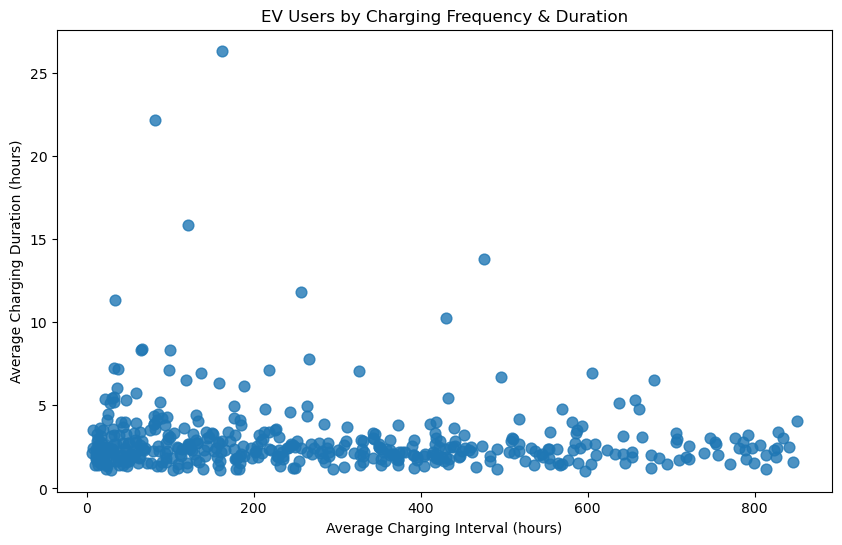

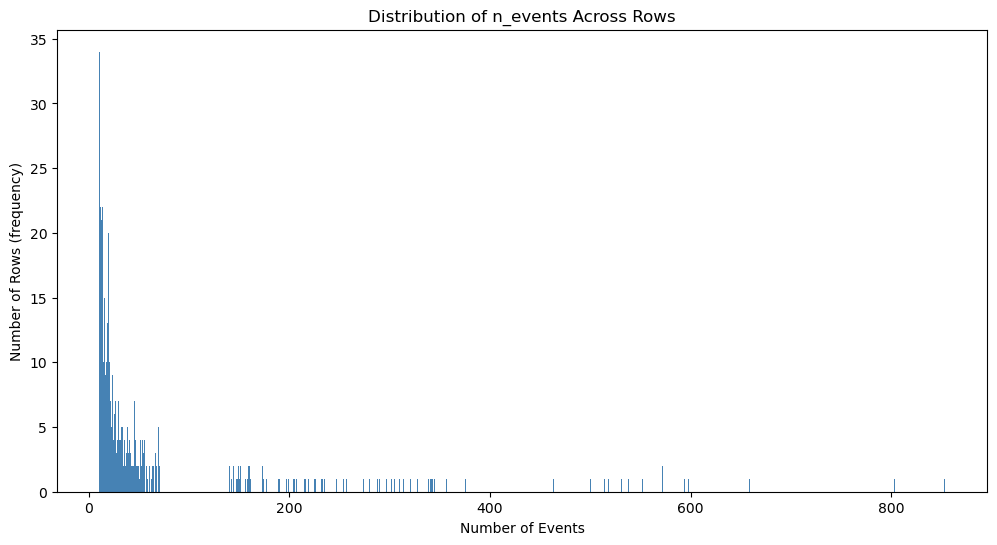

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

def get_start_times(events):
    return pd.to_datetime(
        [e["start"] for e in events],
        format="%d.%m.%Y %H:%M"
    )

def compute_start_intervals(start_times):
    start_times = sorted(start_times)
    return pd.Series(start_times).diff().dropna()

def compute_avg_charging_interval(events):
    if events is None or len(events) < 2:
        return None   # not enough events
    
    start_times = get_start_times(events)
    intervals = compute_start_intervals(start_times)
    
    # Convert to hours
    avg_hours = intervals.dt.total_seconds().mean() / 3600
    return avg_hours


def compute_avg_charge_duration(events):
    if events is None or len(events) == 0:
        return None
    
    durations = []
    
    for e in events:
        start = pd.to_datetime(e["start"], format="%d.%m.%Y %H:%M")
        end   = pd.to_datetime(e["end"],   format="%d.%m.%Y %H:%M")
        
        diff_hours = (end - start).total_seconds() / 3600
        durations.append(diff_hours)
    
    return sum(durations) / len(durations)


# Load parquet
df = pd.read_parquet("ev_detection_results3.parquet")

# Choose a minimum number of events
MIN_EVENTS = 10   # you can change this

# Filter rows that have at least MIN_EVENTS
df_filtered = df[df["events"].str.len() >= MIN_EVENTS].copy()

# Get how many there are
count = len(df_filtered)

print("Number of rows with at least", MIN_EVENTS ,"events:", count)

def compute_min_unique_start_end(events):
    
    # Extract unique start values
    unique_starts = {e["start"] for e in events}

    # Extract unique end values
    unique_ends = {e["end"] for e in events}

    # Take the smaller number
    return min(len(unique_starts), len(unique_ends))

# Apply to each row
df_filtered["min_unique_start_end"] = df_filtered["events"].apply(compute_min_unique_start_end)


df_filtered["difference"] = (df_filtered["n_events"] - df_filtered["min_unique_start_end"])

df_final = df_filtered[df_filtered["min_unique_start_end"] > MIN_EVENTS]

print(len(df_final))

df_final["avg_charging_interval_hours"] = (df_final["events"].apply(compute_avg_charging_interval))


df_final["avg_charge_duration_hours"] = (df_final["events"].apply(compute_avg_charge_duration))


plt.figure(figsize=(10,6))

plt.scatter(
    df_final["avg_charging_interval_hours"],
    df_final["avg_charge_duration_hours"],
    s=60,
    alpha=0.8
)

plt.xlabel("Average Charging Interval (hours)")
plt.ylabel("Average Charging Duration (hours)")
plt.title("EV Users by Charging Frequency & Duration")

plt.show()

counts = df_final["min_unique_start_end"].value_counts().sort_index()

plt.figure(figsize=(12,6))
plt.bar(counts.index, counts.values, color="steelblue")

plt.xlabel("Number of Events")
plt.ylabel("Number of Rows (frequency)")
plt.title("Distribution of n_events Across Rows")

plt.show()


